**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
from collections import Counter
from collections import defaultdict

# Data Preparation

In [3]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii'], inplace=True, errors='ignore')
df_WTout.drop(columns=['PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [4]:
df_WTout

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,Fall,5.0,0.0,Winter,51.00,Fall,46.000,50.8,26.000,73.90,...,Fall,50.55,71.80,Fall,3,16.877316,6.5,12.3225,2.006,448.0
1,Summer,9.0,0.0,Spring,62.55,Fall,48.000,46.0,22.000,75.00,...,Fall,46.00,64.00,Summer,0,14.035590,11.0,20.6250,2.010,334.0
2,Summer,10.0,1.0,Fall,71.00,Fall,56.500,75.6,25.400,65.00,...,Fall,38.00,54.00,Summer,2,16.648696,10.0,12.4500,2.009,453.0
3,Winter,9.0,0.0,Fall,71.00,Summer,56.000,81.6,26.000,60.00,...,Summer,31.00,45.00,Winter,0,18.292347,7.0,20.6250,2.010,577.0
4,Spring,18.0,1.0,Summer,65.00,Spring,55.003,77.0,26.000,68.00,...,Fall,41.60,61.40,Spring,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7.0,1.0,Spring,65.15,Fall,46.070,49.0,22.250,58.50,...,Summer,38.50,55.00,Spring,0,16.229868,7.0,18.0750,2.000,547.7
8456,Winter,10.0,1.0,Spring,69.50,Winter,56.130,47.8,28.500,66.00,...,Winter,40.50,56.95,Winter,0,10.665793,5.0,13.5750,2.000,451.5
8457,Winter,10.0,1.0,Winter,70.00,Winter,49.560,47.2,25.635,63.50,...,Winter,43.75,60.75,Spring,2,13.509359,9.5,21.0375,2.004,528.0
8458,Fall,15.0,1.0,Spring,55.50,Spring,63.790,99.5,31.100,67.70,...,Winter,39.80,56.15,Fall,1,17.189894,10.5,24.4700,2.000,478.0


In [7]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = df_WTout.copy() 

In [8]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [9]:
df = encoder_labels_categoriques(df)

In [10]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [11]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,0,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,0,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,0,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,2,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,0,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0


In [12]:
X.shape

(8460, 83)

In [13]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5833, 1587,  952,   88], dtype=int64))

In [14]:
ctr = Counter(y)
ctr

Counter({0.0: 5833, 1.0: 1587, 2.0: 952, 3.0: 88})

# Data Partitioning

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [17]:
X_train.shape

(5922, 83)

# Classification

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [19]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6540583136327817
F1-score [0.79539067 0.35087719 0.2954955  0.11764706]
              precision    recall  f1-score   support

         0.0      0.783     0.809     0.795      1750
         1.0      0.367     0.336     0.351       476
         2.0      0.305     0.287     0.295       286
         3.0      0.120     0.115     0.118        26

    accuracy                          0.654      2538
   macro avg      0.394     0.387     0.390      2538
weighted avg      0.644     0.654     0.649      2538



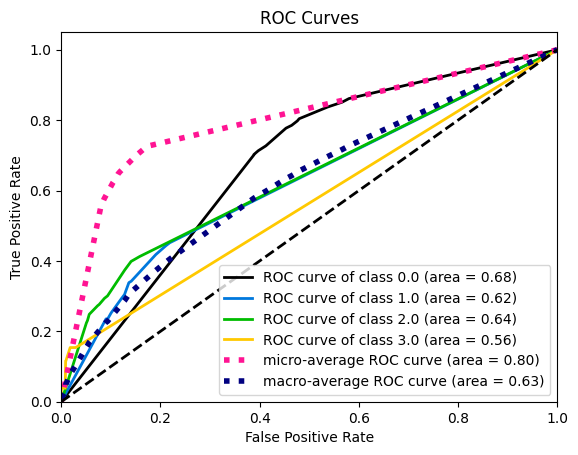

In [20]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

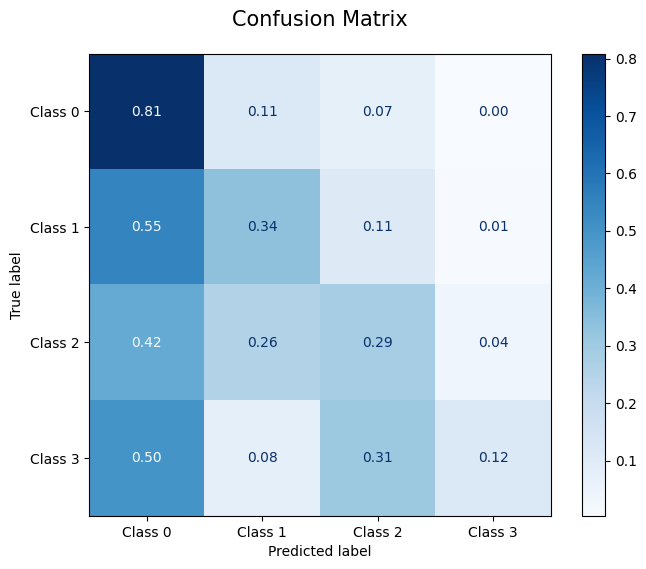

In [21]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [22]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([79,  1,  0,  0,  0,  0,  0,  0,  0,  1], dtype=int64),
 array([7.33745391e-02, 6.63265119e+02, 1.32645686e+03, 1.98964861e+03,
        2.65284035e+03, 3.31603210e+03, 3.97922384e+03, 4.64241559e+03,
        5.30560733e+03, 5.96879908e+03, 6.63199082e+03]))

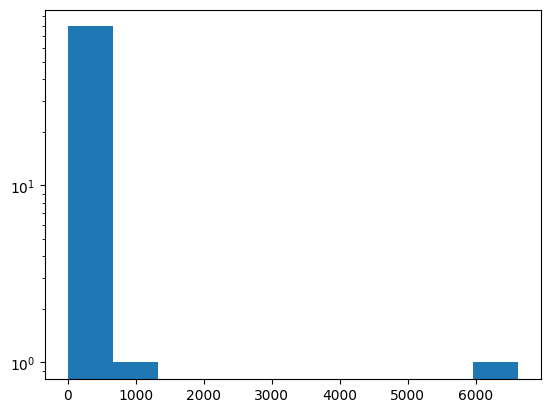

In [23]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [24]:
from sklearn.feature_selection import VarianceThreshold

In [25]:
(.8 * (1 - .8))

0.15999999999999998

In [26]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [27]:
X_train.shape

(5922, 83)

In [28]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6469661150512215
F1-score [0.78811881 0.35820896 0.28209765 0.12      ]
              precision    recall  f1-score   support

         0.0      0.780     0.796     0.788      1750
         1.0      0.364     0.353     0.358       476
         2.0      0.292     0.273     0.282       286
         3.0      0.125     0.115     0.120        26

    accuracy                          0.647      2538
   macro avg      0.390     0.384     0.387      2538
weighted avg      0.640     0.647     0.644      2538



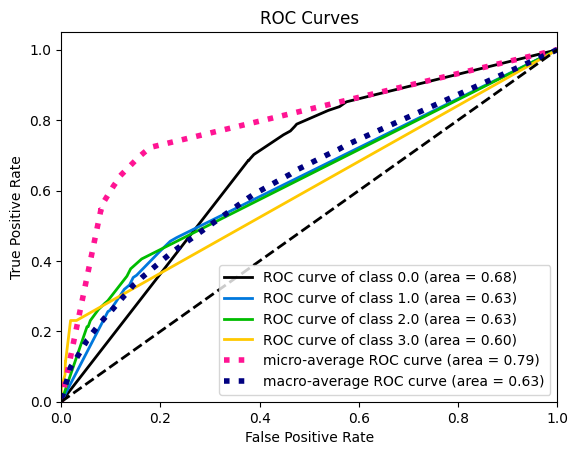

In [29]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

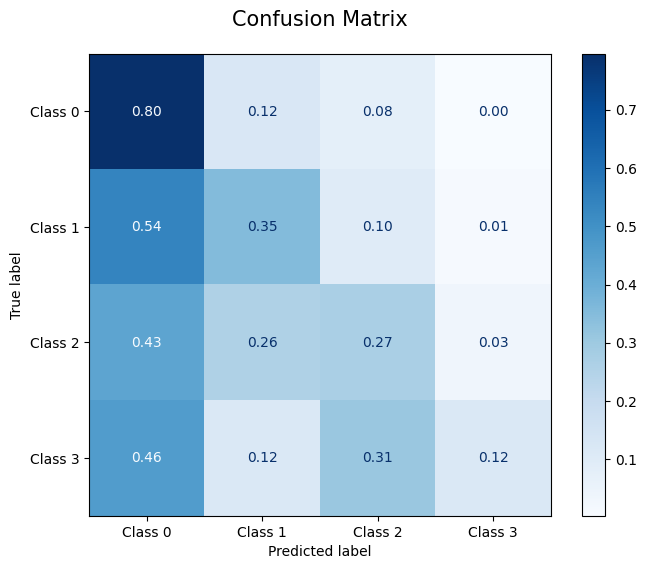

In [30]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [31]:
from sklearn.feature_selection import SelectKBest

In [32]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [33]:
sel.scores_

array([5.28688994e-01, 9.95596036e+01, 1.70857121e+01, 7.35012783e-01,
       1.09599406e+00, 2.02932840e+00, 1.15782637e+02, 7.55611706e+01,
       2.97107408e+01, 6.29437350e+00, 1.40290708e+00, 2.03471300e+01,
       1.22636206e+00, 9.58573154e-01, 1.59775476e+00, 1.09482956e+00,
       4.37951490e-01, 7.82211989e+01, 4.23456647e+00, 1.03045801e+01,
       8.98809543e+00, 6.79925975e+00, 8.91024114e+00, 4.00195170e+01,
       1.58532931e+01, 1.91743496e+00, 1.39611179e+01, 3.41266567e+00,
       9.24982531e+00, 9.89507058e+00, 5.41636540e+00, 3.07617414e+00,
       1.30227308e+00, 1.78207788e+01, 2.62879579e+01, 7.43596871e+01,
       7.89939025e+01, 6.38093265e+01, 8.86642556e+01, 3.10344326e+01,
       3.03176524e+01, 3.89238193e+01, 1.40005544e+01, 7.79635621e+01,
       5.63394603e+01, 8.36278581e+01, 8.16764933e+01, 7.35872012e+01,
       2.75564967e+01, 3.51046500e-01, 4.42509881e+00, 1.39594612e+00,
       7.53032585e-01, 2.43104283e+02, 3.66832914e+02, 3.48721929e+02,
      

In [34]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6713947990543735
F1-score [0.80311025 0.33953998 0.38372093 0.17391304]
              precision    recall  f1-score   support

         0.0      0.781     0.826     0.803      1750
         1.0      0.355     0.326     0.340       476
         2.0      0.430     0.346     0.384       286
         3.0      0.200     0.154     0.174        26

    accuracy                          0.671      2538
   macro avg      0.442     0.413     0.425      2538
weighted avg      0.656     0.671     0.662      2538



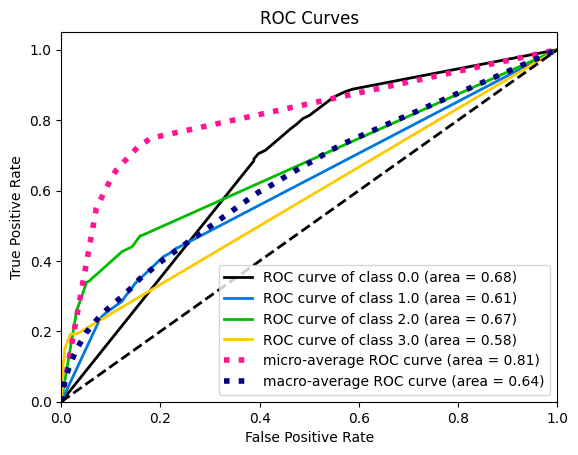

In [35]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

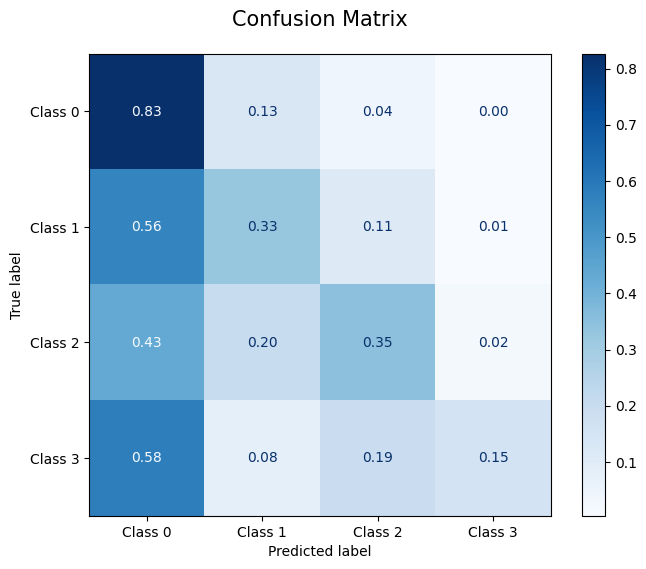

In [37]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [38]:
from sklearn.feature_selection import RFE

In [39]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [40]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.5795902285263987
F1-score [0.7391669  0.22106361 0.1617357  0.12121212]
              precision    recall  f1-score   support

         0.0      0.724     0.755     0.739      1750
         1.0      0.219     0.223     0.221       476
         2.0      0.186     0.143     0.162       286
         3.0      0.286     0.077     0.121        26

    accuracy                          0.580      2538
   macro avg      0.354     0.300     0.311      2538
weighted avg      0.564     0.580     0.571      2538



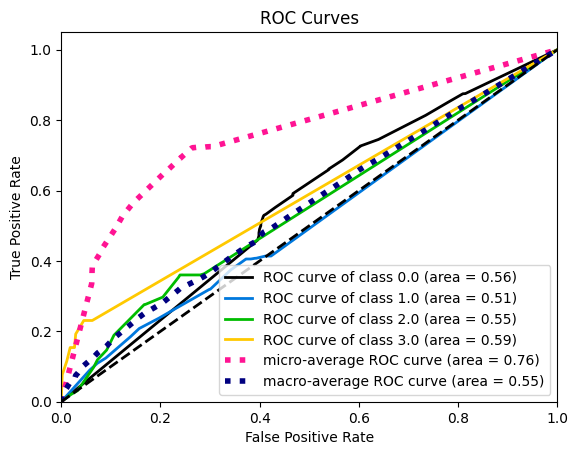

In [41]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

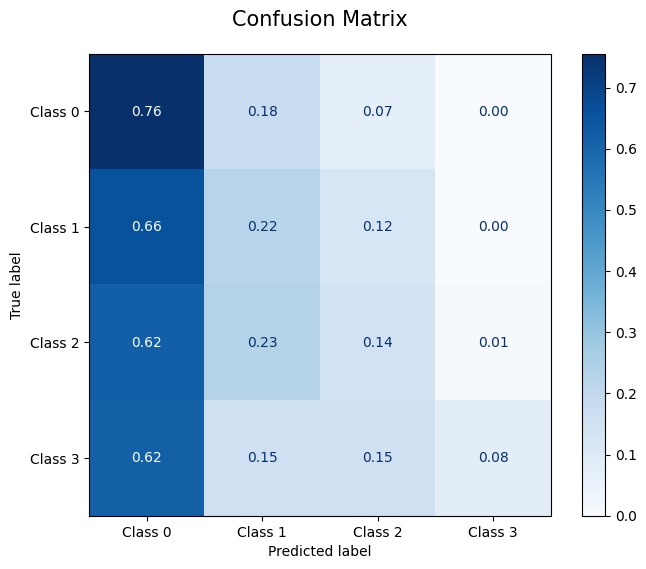

In [42]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [43]:
from sklearn.feature_selection import SelectFromModel

In [44]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 33)

In [45]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6670606776989756
F1-score [0.8        0.35775862 0.38297872 0.13636364]
              precision    recall  f1-score   support

         0.0      0.791     0.809     0.800      1750
         1.0      0.367     0.349     0.358       476
         2.0      0.388     0.378     0.383       286
         3.0      0.167     0.115     0.136        26

    accuracy                          0.667      2538
   macro avg      0.428     0.413     0.419      2538
weighted avg      0.660     0.667     0.663      2538



In [46]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                         Feature  Importance
21                PCIAT-PCIAT_05    0.130893
2                Physical-Height    0.052764
5             Physical-HeartRate    0.042129
29             SDS-SDS_Total_Raw    0.037222
12                   BIA-BIA_DEE    0.033591
13                   BIA-BIA_ECW    0.032666
15                   BIA-BIA_ICW    0.032506
4   Physical-Waist_Circumference    0.032476
31              Physical-BMI_New    0.032320
24                PCIAT-PCIAT_15    0.031593
30               SDS-SDS_Total_T    0.031074
20                PCIAT-PCIAT_02    0.029883
32                  FGC_Grip_Avg    0.029603
1                CGAS-CGAS_Score    0.028847
16                   BIA-BIA_LDM    0.028681
17                   BIA-BIA_LST    0.028635
18                   BIA-BIA_TBW    0.028290
6           Physical-Systolic_BP    0.027810
25                PCIAT-PCIAT_16    0.027321
23                PCIAT-PCIAT_14    0.026474
8     Fitness_Endurance-Time_Sec    0.025547
3         

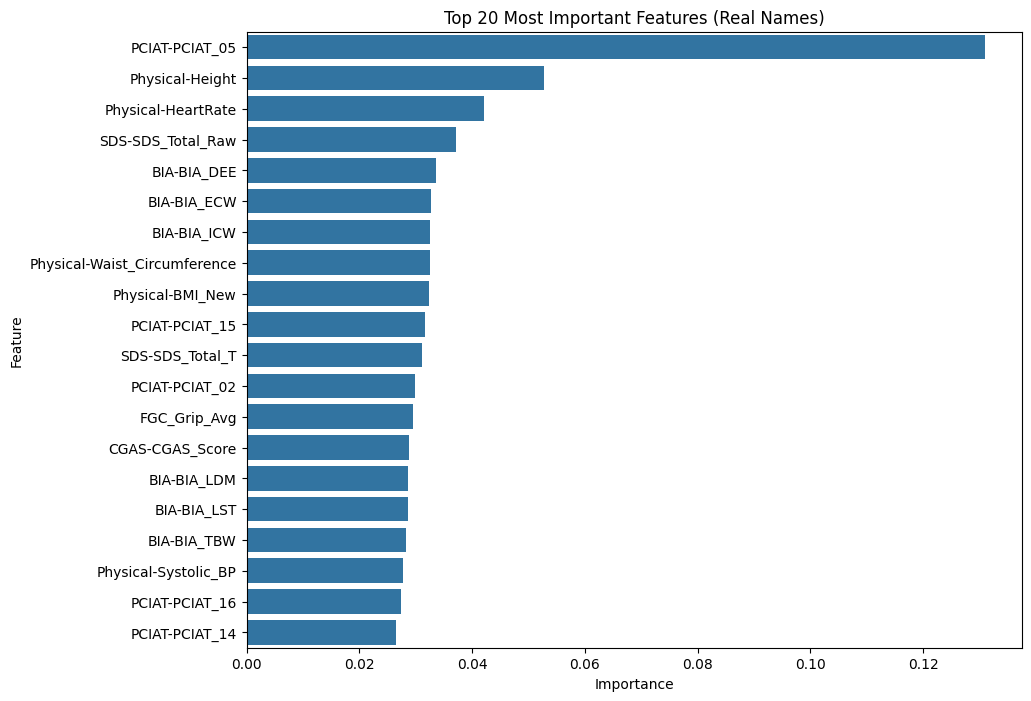

In [47]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

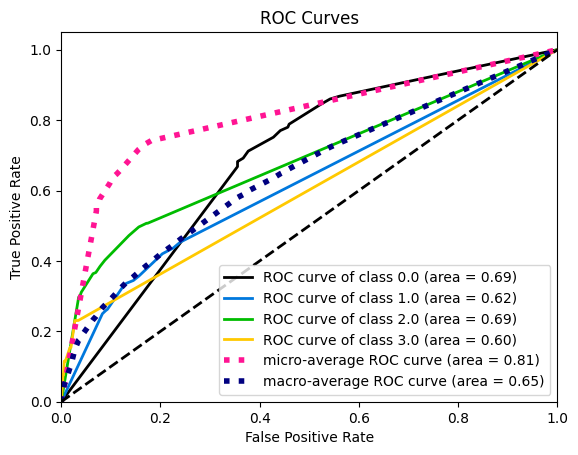

In [48]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

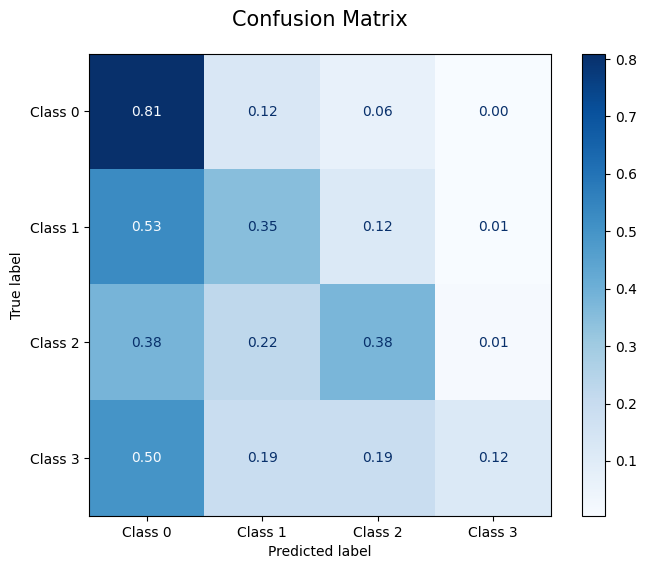

In [49]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [50]:
import xgboost as xgb

In [51]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 21)

In [52]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6737588652482269
F1-score [0.80559441 0.37671958 0.34749035 0.10526316]
              precision    recall  f1-score   support

         0.0      0.789     0.823     0.806      1750
         1.0      0.380     0.374     0.377       476
         2.0      0.388     0.315     0.347       286
         3.0      0.167     0.077     0.105        26

    accuracy                          0.674      2538
   macro avg      0.431     0.397     0.409      2538
weighted avg      0.661     0.674     0.666      2538



In [53]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f57', 9.62059497833252), ('f67', 5.742372989654541), ('f70', 5.417903423309326), ('f56', 4.744637489318848), ('f69', 3.3965818881988525), ('f54', 3.2147693634033203), ('f65', 2.7418081760406494), ('f66', 2.7388367652893066), ('f71', 2.3019649982452393), ('f68', 2.293346881866455), ('f72', 2.232144355773926), ('f63', 2.1929233074188232), ('f6', 2.119084119796753), ('f44', 2.0011746883392334), ('f60', 1.8999335765838623), ('f62', 1.8565722703933716), ('f49', 1.8421871662139893), ('f55', 1.7746046781539917), ('f28', 1.7510572671890259), ('f64', 1.7235959768295288), ('f22', 1.5835553407669067), ('f80', 1.49262535572052), ('f59', 1.4449483156204224), ('f53', 1.4421145915985107), ('f47', 1.4335345029830933), ('f17', 1.405522108078003), ('f73', 1.3701529502868652), ('f38', 1.3564344644546509), ('f46', 1.350109338760376), ('f29', 1.3185640573501587), ('f14', 1.3145875930786133), ('f35', 1.2944988012313843), ('f36', 1.2935161590576172), ('f7', 1.2928264141082764), ('f4', 1.2789098024368286),

In [55]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- XGboost feature Importance ---")
print(dt_importance.head(20))

--- XGboost feature Importance ---
              Feature  Importance
0     Physical-Height    0.210855
3         BIA-BIA_LDM    0.172114
8      PCIAT-PCIAT_05    0.157638
4   PAQ_A-PAQ_A_Total    0.060590
15     PCIAT-PCIAT_15    0.046139
16     PCIAT-PCIAT_16    0.040866
14     PCIAT-PCIAT_14    0.036276
7      PCIAT-PCIAT_04    0.032407
17     PCIAT-PCIAT_17    0.031589
5      PCIAT-PCIAT_02    0.031008
19     PCIAT-PCIAT_19    0.027147
11     PCIAT-PCIAT_11    0.026862
13     PCIAT-PCIAT_13    0.022033
10     PCIAT-PCIAT_10    0.020890
9      PCIAT-PCIAT_08    0.015967
2    FGC-FGC_SRR_Zone    0.014770
20     PCIAT-PCIAT_20    0.013691
12     PCIAT-PCIAT_12    0.011531
6      PCIAT-PCIAT_03    0.011087
18     PCIAT-PCIAT_18    0.010716


In [56]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
           Feature      Gain
57  PCIAT-PCIAT_05  9.620595
67  PCIAT-PCIAT_15  5.742373
70  PCIAT-PCIAT_18  5.417903
56  PCIAT-PCIAT_04  4.744637
69  PCIAT-PCIAT_17  3.396582
54  PCIAT-PCIAT_02  3.214769
65  PCIAT-PCIAT_13  2.741808
66  PCIAT-PCIAT_14  2.738837
71  PCIAT-PCIAT_19  2.301965
68  PCIAT-PCIAT_16  2.293347


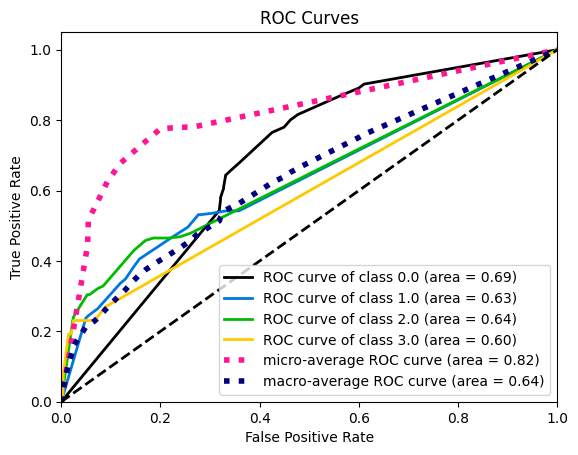

In [57]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

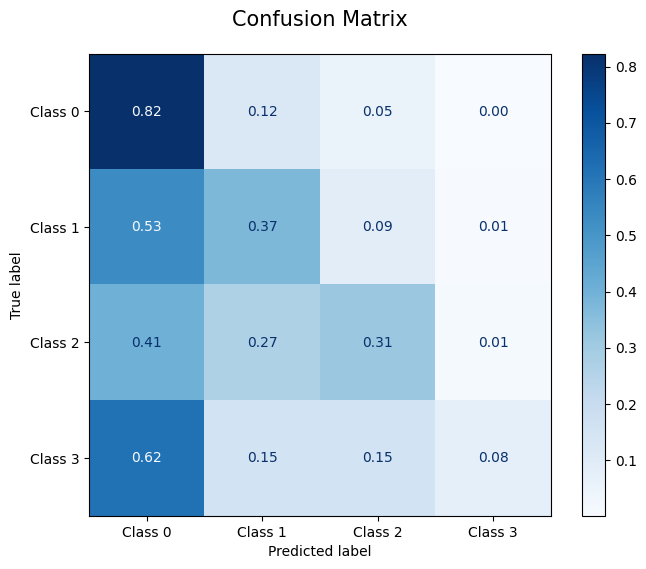

In [58]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [59]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [62]:
X_train_pca.shape

(5922, 2)

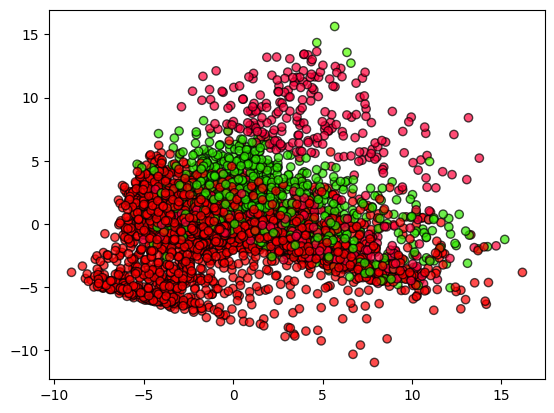

In [63]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [64]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7021276595744681
F1-score [0.81790882 0.38262911 0.44274809 0.27027027]
              precision    recall  f1-score   support

         0.0       0.78      0.86      0.82      1750
         1.0       0.43      0.34      0.38       476
         2.0       0.49      0.41      0.44       286
         3.0       0.45      0.19      0.27        26

    accuracy                           0.70      2538
   macro avg       0.54      0.45      0.48      2538
weighted avg       0.68      0.70      0.69      2538



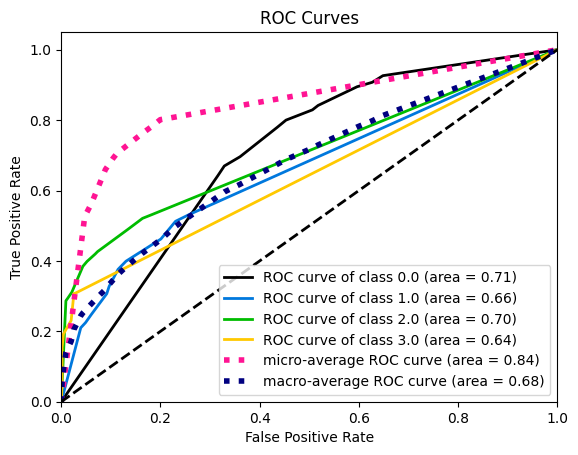

In [65]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

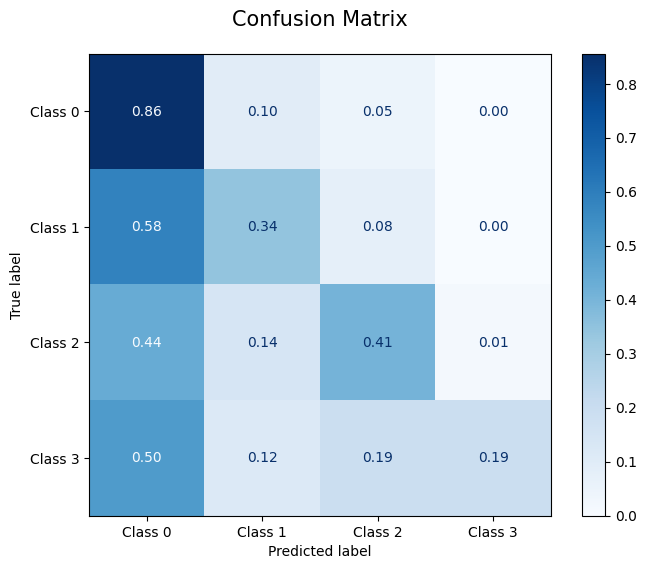

In [66]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

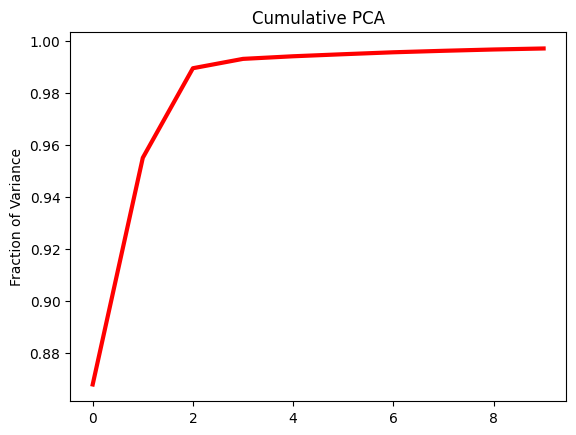

In [67]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

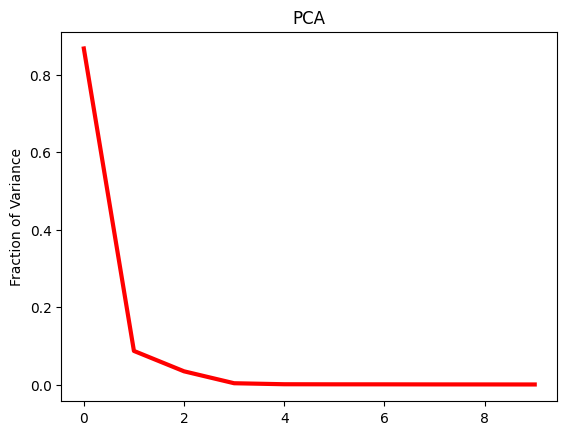

In [68]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [69]:
from sklearn import random_projection

In [70]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

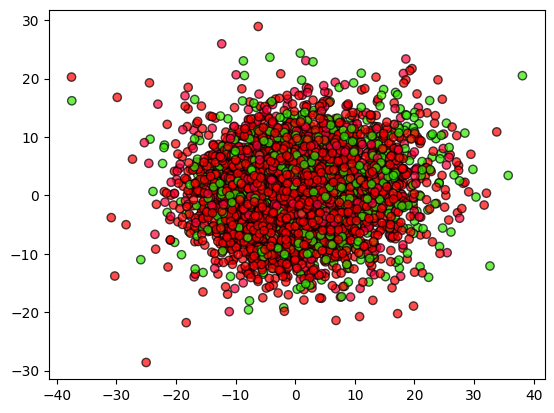

In [71]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [72]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5646178092986603
F1-score [0.72642799 0.17016575 0.10810811 0.06451613]
              precision    recall  f1-score   support

         0.0       0.70      0.76      0.73      1750
         1.0       0.18      0.16      0.17       476
         2.0       0.13      0.09      0.11       286
         3.0       0.20      0.04      0.06        26

    accuracy                           0.56      2538
   macro avg       0.30      0.26      0.27      2538
weighted avg       0.53      0.56      0.55      2538



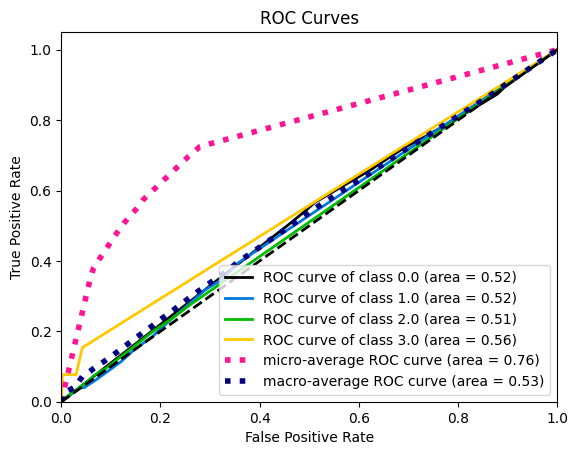

In [73]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

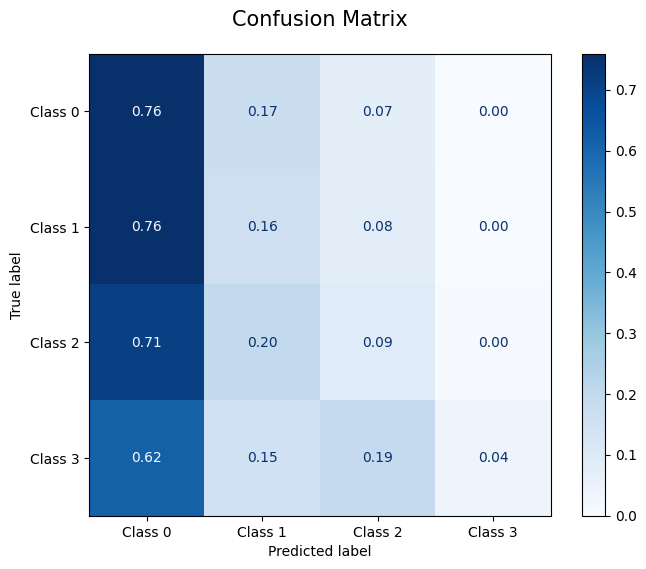

In [74]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [75]:
from sklearn.manifold import MDS

In [76]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


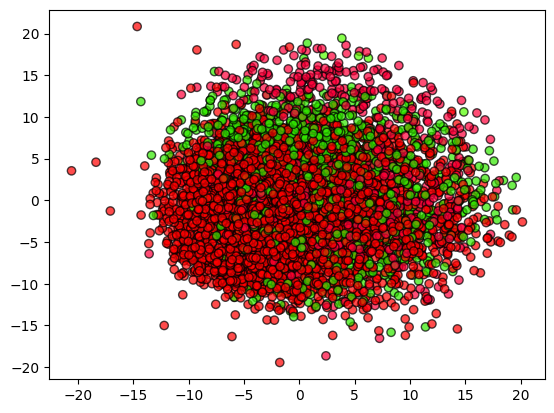

In [77]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [78]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8537656197230665
F1-score [0.91415752 0.73267327 0.67296137 0.35955056]
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91      4083
         1.0       0.77      0.70      0.73      1111
         2.0       0.79      0.59      0.67       666
         3.0       0.59      0.26      0.36        62

    accuracy                           0.85      5922
   macro avg       0.76      0.62      0.67      5922
weighted avg       0.85      0.85      0.85      5922



## IsoMap

In [79]:
from sklearn.manifold import Isomap

In [80]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

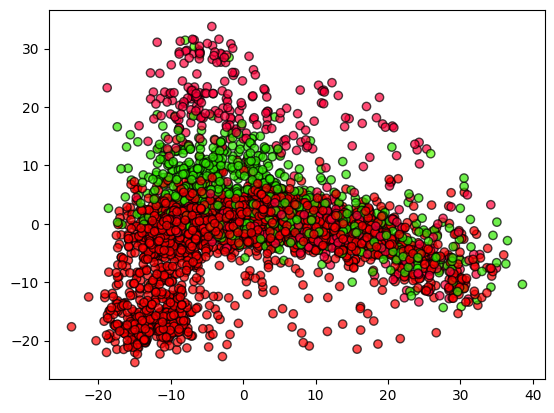

In [81]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [82]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6658786446020488
F1-score [0.79614856 0.32035595 0.39034205 0.08888889]
              precision    recall  f1-score   support

         0.0       0.77      0.83      0.80      1750
         1.0       0.34      0.30      0.32       476
         2.0       0.46      0.34      0.39       286
         3.0       0.11      0.08      0.09        26

    accuracy                           0.67      2538
   macro avg       0.42      0.39      0.40      2538
weighted avg       0.65      0.67      0.65      2538



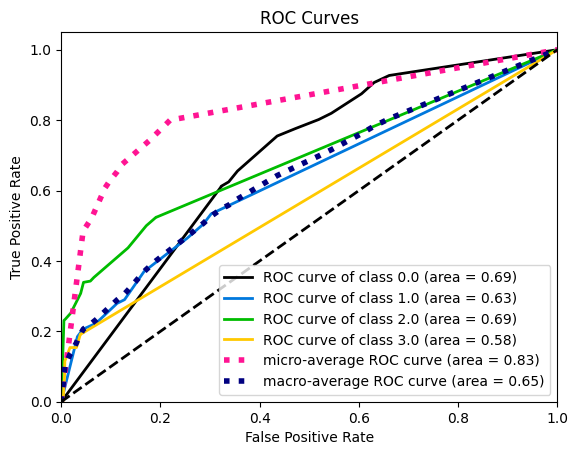

In [83]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

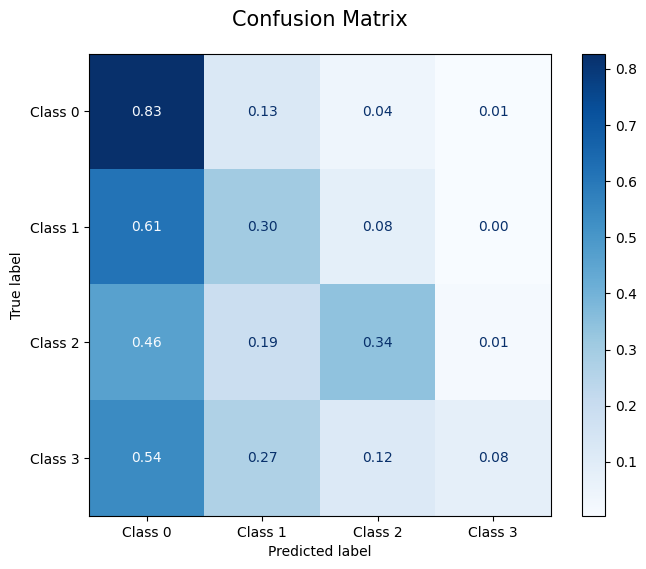

In [84]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [85]:
from sklearn.manifold import TSNE

In [86]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

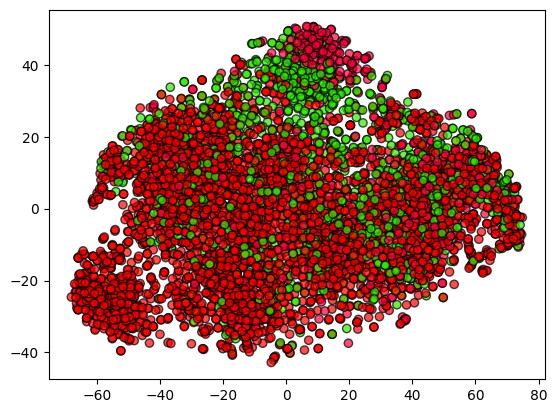

In [87]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [88]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8677811550151976
F1-score [0.92349857 0.76309689 0.70529801 0.34482759]
              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92      4083
         1.0       0.79      0.74      0.76      1111
         2.0       0.79      0.64      0.71       666
         3.0       0.60      0.24      0.34        62

    accuracy                           0.87      5922
   macro avg       0.77      0.64      0.68      5922
weighted avg       0.86      0.87      0.86      5922

